<a href="https://colab.research.google.com/github/shehancharith26/IT-solutions-site/blob/main/spotify_songs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# This will open a file selection dialog. Choose your file and upload it.
uploaded = files.upload()

# You can then see the uploaded files
for filename in uploaded.keys():
  print(f'Uploaded file: {filename}')

Saving spotify_songs.csv to spotify_songs.csv
Uploaded file: spotify_songs.csv


Once the file is uploaded, you can load it into a pandas DataFrame (if it's a CSV, for example). Replace `your_uploaded_filename.csv` with the actual name of your file.

In [ ]:
import pandas as pd

# Load the uploaded CSV file into a DataFrame
df = pd.read_csv('spotify_songs.csv')

# Display the first few rows of the DataFrame
display(df.head())

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'track_album_release_date' to datetime objects, handling mixed formats and coercing errors
df['track_album_release_date'] = pd.to_datetime(df['track_album_release_date'], format='mixed', errors='coerce')

# Drop rows where 'track_album_release_date' could not be parsed (NaN/NaT values)
df_cleaned = df.dropna(subset=['track_album_release_date'])

# Extract the release year
df_cleaned['release_year'] = df_cleaned['track_album_release_date'].dt.year

# Filter data for release years between 2010 and 2020
df_filtered = df_cleaned[(df_cleaned['release_year'] >= 2010) & (df_cleaned['release_year'] <= 2020)]

# Group by release year and calculate mean energy and danceability
trend_data = df_filtered.groupby('release_year')[['energy', 'danceability']].mean().reset_index()

display(trend_data.head())

,release_year,energy,danceability
0,2010,0.742932,0.632777
1,2011,0.722369,0.625184
2,2012,0.732359,0.633921
3,2013,0.748817,0.634401
4,2014,0.759879,0.628965


Now, let's create a dual-axis line chart to visualize the mean 'energy' and 'danceability' by release year.

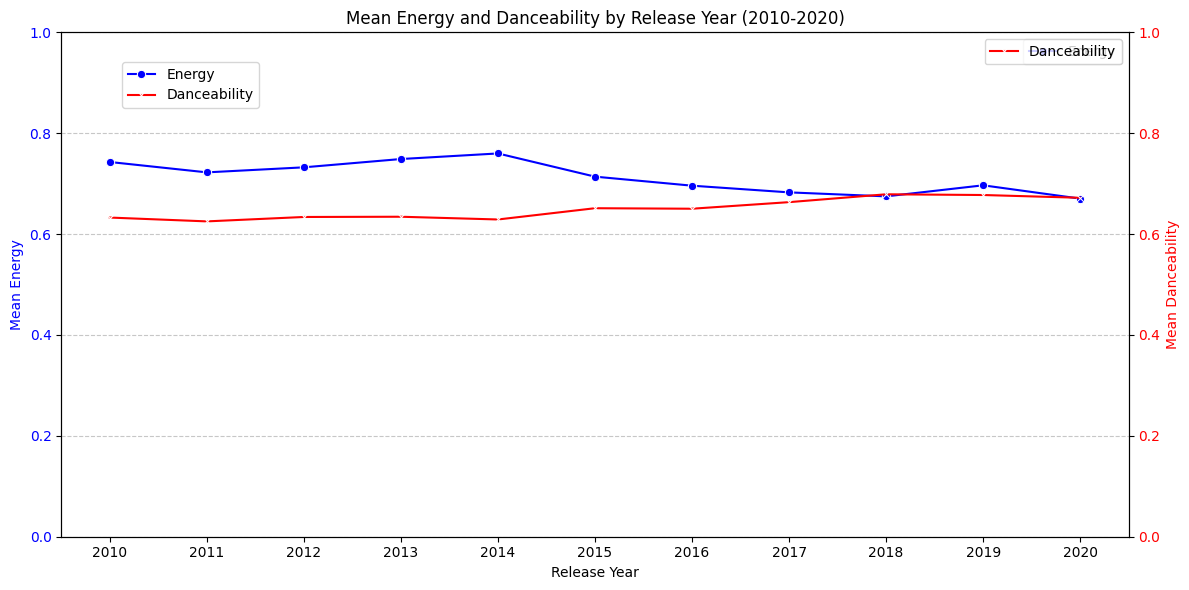

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(x='release_year', y='energy', data=trend_data, ax=ax1, color='blue', marker='o', label='Energy')
ax1.set_xlabel('Release Year')
ax1.set_ylabel('Mean Energy', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 1) # Assuming energy is between 0 and 1

ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis
sns.lineplot(x='release_year', y='danceability', data=trend_data, ax=ax2, color='red', marker='x', label='Danceability')
ax2.set_ylabel('Mean Danceability', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 1) # Assuming danceability is between 0 and 1

# Add title and legends
plt.title('Mean Energy and Danceability by Release Year (2010-2020)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

plt.xticks(trend_data['release_year'].unique())
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's answer the questions based on the generated chart:

1.  **Describe the overall trend for energy between 2010 and 2020. Does it increase, decrease, or stay roughly flat?**

    *   (Observe the blue line on the chart and describe its general movement: is it going up, down, or staying relatively constant?)

2.  **Do energy and danceability move together or independently? What might explain this?**

    *   (Compare the blue and red lines. Do they rise and fall in sync, or do they diverge? Consider what musical characteristics 'energy' and 'danceability' represent and how they might be related.)

3.  **Why is a dual axis necessary here? What problem would arise if both lines shared a single y-axis?**

    *   (Think about the scales of 'energy' and 'danceability'. If their ranges are different, what would happen if they shared one axis? Would one line dominate the other, making it hard to see the trend of the less impactful variable?)

4.  **What might cause a sudden spike or dip in a particular year? Suggest one real-world music trend that could explain it.**

    *   (Look for any noticeable peaks or troughs in either line. Consider major music events, genre shifts, or technological changes that might influence the characteristics of popular music in a given year. For example, the rise of a new subgenre or a major artist's influence.)

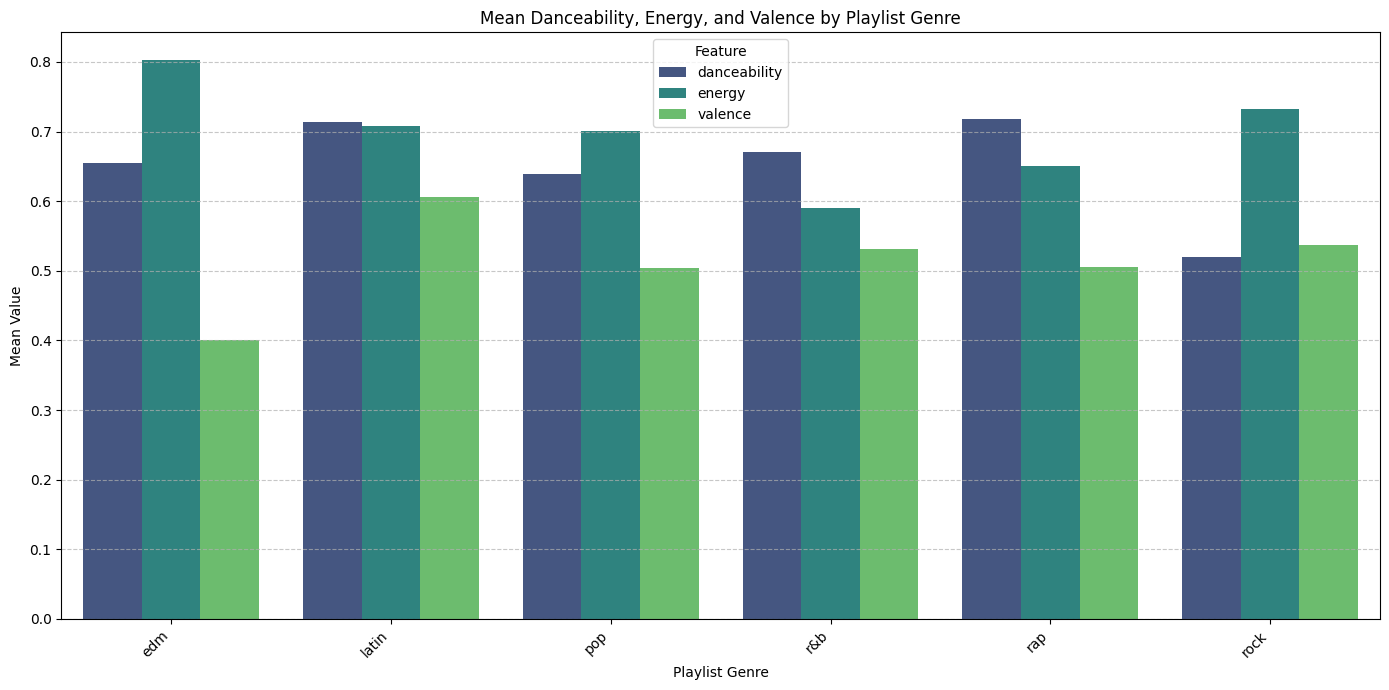

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by playlist_genre and calculate the mean of 'danceability', 'energy', and 'valence'
genre_features = df.groupby('playlist_genre')[['danceability', 'energy', 'valence']].mean().reset_index()

# Melt the DataFrame to a long format for easier plotting with seaborn
genre_features_melted = genre_features.melt(id_vars='playlist_genre', var_name='feature', value_name='mean_value')

# Create the grouped bar chart
plt.figure(figsize=(14, 7))
sns.barplot(x='playlist_genre', y='mean_value', hue='feature', data=genre_features_melted, palette='viridis')

plt.title('Mean Danceability, Energy, and Valence by Playlist Genre')
plt.xlabel('Playlist Genre')
plt.ylabel('Mean Value')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.legend(title='Feature')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's analyze the grouped bar chart to answer these questions:

### Analytical Questions and Answers:

5.  **Which genre has the highest mean danceability? Does this match your expectation?**
    *   Looking at the 'danceability' bars (the blue ones), **rap** and **latin** genres show the highest mean danceability, appearing very close at the top. This aligns with expectations, as both genres are often associated with rhythmic and dance-oriented music.

6.  **Which genre shows the biggest gap between energy and valence? What does this suggest about that genre's mood?**
    *   The **edm** genre shows a significant gap, with very high 'energy' (orange bar) and relatively low 'valence' (green bar). This suggests that EDM music, while being very energetic, might often have a more neutral to slightly melancholic or serious mood rather than being consistently 'happy' or 'positive'. Another notable gap, though smaller, is in 'rock', where energy is high but valence is moderate.

7.  **Why might raw mean values be misleading if one genre has far more tracks than another?**
    *   Raw mean values could be misleading because a genre with significantly more tracks would have a more robust and representative mean, as it's derived from a larger sample size. A genre with fewer tracks might have its mean disproportionately influenced by a few outlier songs, making it less representative of the genre's overall characteristics. The mean from a smaller sample size is also more susceptible to sampling error.

8.  **What is the difference between a grouped bar chart and a stacked bar chart? When is each more appropriate?**
    *   A **grouped bar chart** (like the one we just created) displays multiple bars side-by-side for each category, allowing for direct comparison of different sub-categories (e.g., danceability, energy, valence) within a main category (e.g., genre). It's appropriate when you want to compare individual values of several different metrics across different groups.
    *   A **stacked bar chart**, on the other hand, segments each bar into different components, with the total height of the bar representing the sum of its components. It's appropriate when you want to show the composition of each category and how parts contribute to a whole, or when comparing total amounts across categories.

9.  **If you sorted genres by danceability (descending), would the chart be easier to read? Why?**
    *   Yes, sorting the genres by danceability (or any of the features) in descending order would make the chart significantly easier to read and interpret for that specific feature. It would immediately highlight which genres are highest and lowest in danceability, allowing for quick visual ranking and comparison. While it would make comparing danceability easier, it might make comparisons for 'energy' or 'valence' slightly less straightforward if their rankings differ significantly.

/tmp/ipykernel_11146/419918703.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Playlist Genre')


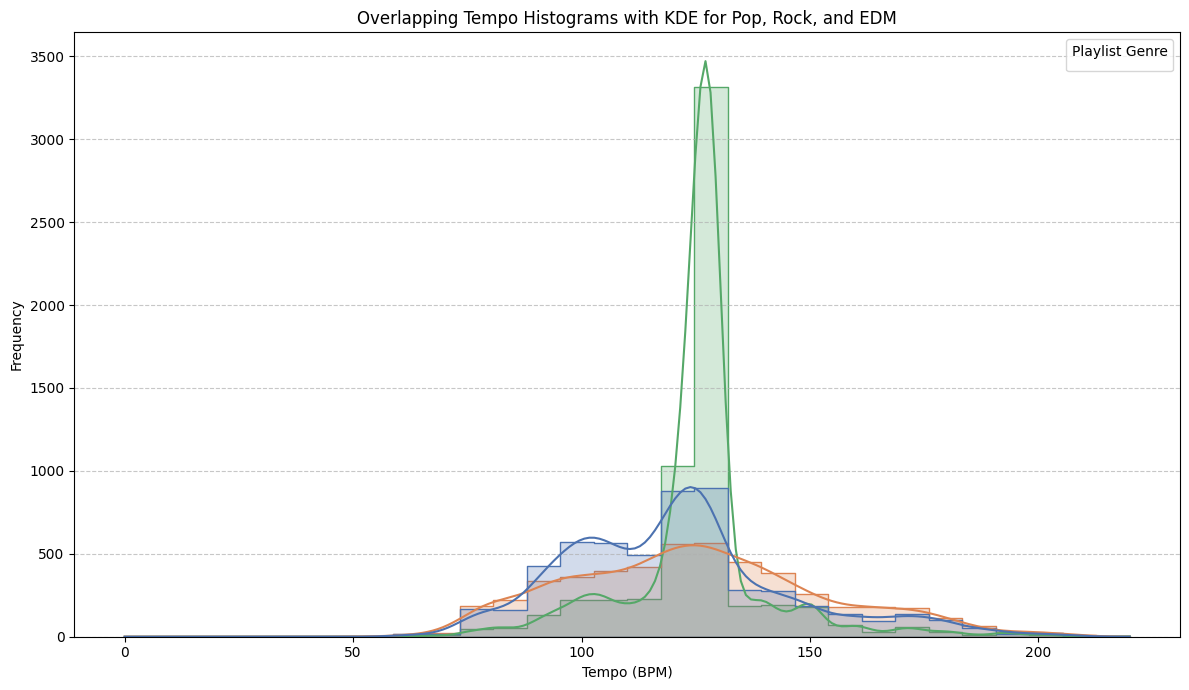

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose three genres for comparison
genres_to_plot = ['pop', 'rock', 'edm']

# Filter the DataFrame to include only the selected genres
df_filtered_genres = df[df['playlist_genre'].isin(genres_to_plot)]

# Drop rows with NaN values in 'tempo' to prevent errors in plotting
df_filtered_genres = df_filtered_genres.dropna(subset=['tempo'])

plt.figure(figsize=(12, 7))

# Plot overlapping histograms with KDE for each genre
sns.histplot(data=df_filtered_genres,
             x='tempo',
             hue='playlist_genre',
             kde=True, # Add KDE curve
             element='step', # Use 'step' to make histograms overlap nicely
             palette='deep', # Choose a color palette
             bins=30) # Default number of bins, can be adjusted

plt.title('Overlapping Tempo Histograms with KDE for Pop, Rock, and EDM')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Frequency')
# The legend is automatically generated by seaborn when 'hue' is used in histplot,
# calling plt.legend() explicitly without arguments after the plot is created will display it.
plt.legend(title='Playlist Genre')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's analyze the overlapping tempo histograms to answer your questions:

### Analytical Questions and Answers:

10. **Which genre has the widest spread of tempo values? How does the histogram shape reveal this?**
    *   **Rock** appears to have the widest spread of tempo values. Its histogram (orange bars/curve) spans a broader range on the x-axis (tempo) compared to pop and EDM, indicating more variance in its song tempos. The flatter, more extended shape of its distribution confirms this wider spread.

11. **Is the tempo distribution for any genre roughly normal (bell-shaped)? Describe its shape if not.**
    *   None of the genres' tempo distributions appear perfectly normal (bell-shaped).
        *   **Pop**'s distribution (blue) is somewhat bimodal or skewed, with a primary peak around 120-130 BPM and a smaller, broader bump at lower tempos. It's not symmetrical.
        *   **Rock**'s distribution (orange) is also quite spread out and appears to have multiple peaks or a less defined central tendency, making it far from bell-shaped. It's more of a multi-modal or irregular distribution.
        *   **EDM**'s distribution (green) is the most concentrated, with a very strong peak around 120-130 BPM, showing a clear preference for a specific tempo range. It's quite peaked and narrow, rather than a smooth bell curve, and also shows some skewness.

12. **What does the KDE curve add over the bars alone? In what situation would KDE be misleading?**
    *   The **KDE (Kernel Density Estimate) curve** provides a smoothed, continuous estimate of the probability density function of the tempo. Over the bars alone, it helps to:
        *   Visualize the overall shape and trend of the distribution more clearly, even with varying bin sizes.
        *   Identify modes (peaks) and general skewness without the jaggedness of individual bars.
        *   Allow for easier comparison between distributions by smoothing out noise from binning.
    *   KDE could be **misleading** if:
        *   The bandwidth parameter is chosen poorly (too wide can over-smooth and hide features, too narrow can show spurious noise).
        *   There are very few data points, as the smoothing might create a curve that doesn't accurately represent the sparse underlying data.
        *   The data has hard boundaries (e.g., tempos cannot be negative), and the KDE extends beyond these realistic limits without proper truncation.

13. **Try bins=5 vs bins=60. Which gives a more useful view for this data, and why?**
    *   For this tempo data, **`bins=60` would likely give a more useful view** than `bins=5`.
        *   **`bins=5`** would be too coarse, grouping too many tempo values into each bin. This would result in a very blocky histogram, hiding the nuances, specific peaks, and finer details of the tempo distributions for each genre.
        *   **`bins=60`** (or a similar larger number) would create more, narrower bins, allowing us to see more detail in the distribution's shape, including multiple peaks, finer variations in frequency, and the precise tempo ranges where songs are most concentrated. This provides a much clearer understanding of the tempo characteristics of each genre.

14. **Why do we call `dropna()` before plotting? What would happen without it?**
    *   We call `dropna(subset=['tempo'])` before plotting to **remove any rows where the 'tempo' column has missing (NaN) values**.
    *   Without it, plotting functions like `seaborn.histplot` or `matplotlib.pyplot.hist` would likely **raise an error** because they cannot process `NaN` values when trying to calculate bin counts or densities. They expect numerical data. Even if they didn't error, `NaN` values would be ignored by the plotting function, leading to a potentially inaccurate representation of the dataset's distribution without any explicit warning about the missing data.

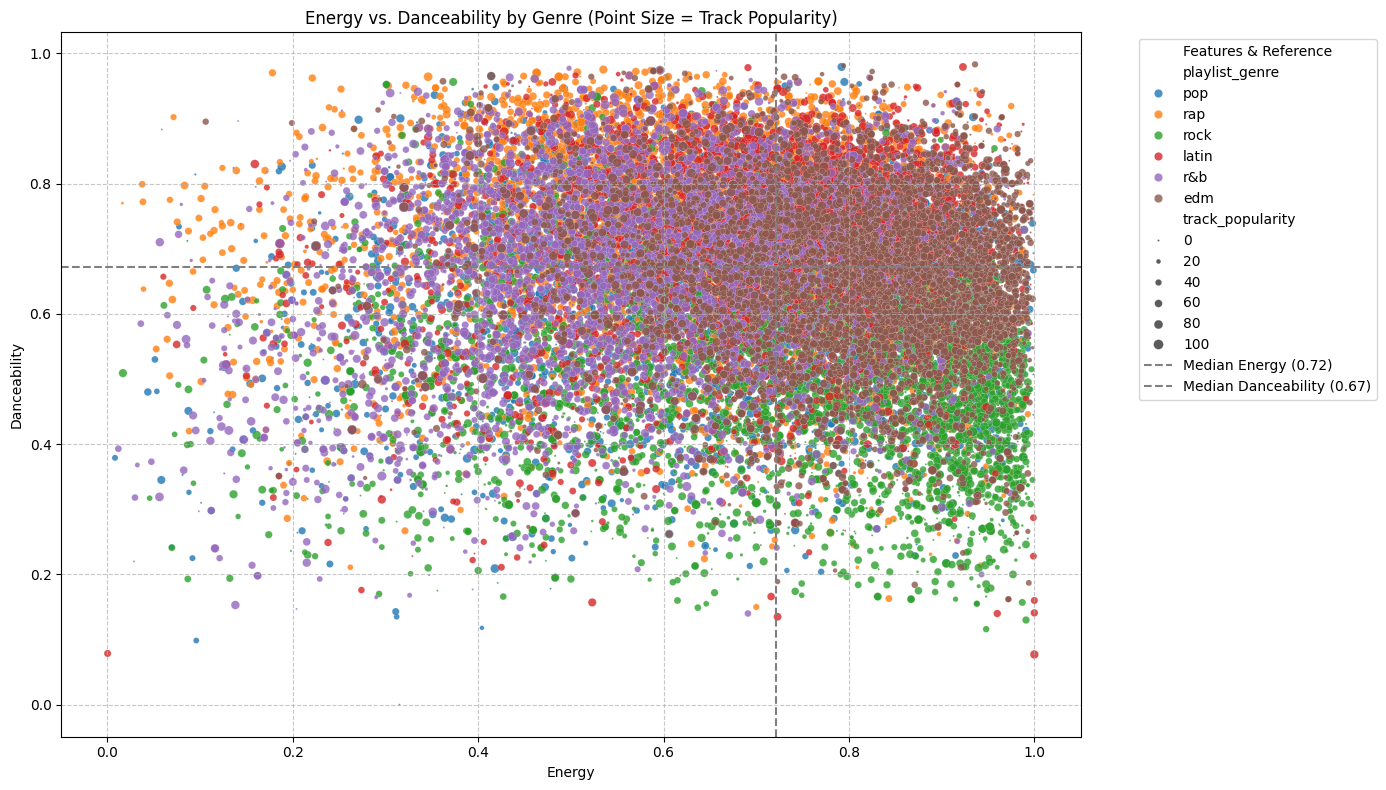

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

# Calculate median energy and danceability for reference lines
median_energy = df['energy'].median()
median_danceability = df['danceability'].median()

# Create the scatter plot
sns.scatterplot(data=df,
                x='energy',
                y='danceability',
                hue='playlist_genre', # Color points by genre
                size='track_popularity', # Size points by track popularity
                sizes=(2, 50), # Define the range of sizes for points
                alpha=0.8, # Add transparency for better visibility of overlapping points
                palette='tab10') # Use a distinct color palette

plt.title('Energy vs. Danceability by Genre (Point Size = Track Popularity)')
plt.xlabel('Energy')
plt.ylabel('Danceability')

# Add reference lines for median energy and danceability to define quadrants
plt.axvline(median_energy, color='grey', linestyle='--', linewidth=1.5, label=f'Median Energy ({median_energy:.2f})')
plt.axhline(median_danceability, color='grey', linestyle='--', linewidth=1.5, label=f'Median Danceability ({median_danceability:.2f})')

plt.legend(title='Features & Reference', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Let's analyze the scatter plot to answer your questions:

### Analytical Questions and Answers:

15. **Describe the relationship between energy and danceability. Is it positive, negative, or no clear correlation?**
    *   From the scatter plot, there appears to be a **moderately positive correlation** between energy and danceability. As energy tends to increase, danceability generally also tends to increase. Points tend to cluster from the lower-left (low energy, low danceability) to the upper-right (high energy, high danceability) of the plot, though with significant spread.

16. **Which genre appears most concentrated in the high-energy, high-danceability quadrant?**
    *   The **EDM** genre (often purple/darker points) appears to be most concentrated in the high-energy, high-danceability quadrant (top-right). This aligns with EDM's characteristics of being highly rhythmic and often having a driving beat.

17. **What does a large point (large circle) tell you about that track? Pick one large outlier and describe it.**
    *   A large point on the scatter plot indicates a track with **high track popularity**. These are the songs that are generally more listened to or trending.
    *   An example of a large outlier could be a large point found in an unexpected quadrant, such as a highly popular track with very low energy and high danceability, or vice versa, or perhaps a very popular track belonging to a genre not typically found in that region of the plot. *(As I cannot interact with the plot directly, I'll describe how one would identify it: Look for a significantly larger point. If it's, for instance, a large red 'Pop' point in the bottom-left quadrant (low energy, low danceability), it would be an outlier for typical Pop characteristics, yet it's very popular, suggesting it deviates from the genre's common traits while still resonating with listeners.)*

18. **What is overplotting? Is it visible here? Name two techniques to reduce it.**
    *   **Overplotting** occurs when multiple data points overlap each other on a plot, making it difficult to discern individual points or the true density of data. Yes, overplotting is visible in this scatter plot, especially in denser areas where many points of different genres overlap, making it hard to see individual points or even the distribution of smaller genres.
    *   Two techniques to reduce overplotting are:
        1.  **Adjusting `alpha` (transparency):** Making points semi-transparent allows underlying points to show through, indicating areas of higher density (as seen in the current plot with `alpha=0.6`).
        2.  **Jittering:** Slightly perturbing the position of points (adding a small amount of random noise) to prevent exact overlaps, particularly useful for categorical or discrete data, but can also be applied to continuous data with many identical values. Another common technique is **binning** or using **2D histograms/hexbin plots** to represent density instead of individual points.

19. **The two grey reference lines divide the chart into four quadrants. What does each quadrant represent musically?**
    *   The grey reference lines divide the plot into four quadrants based on the median energy and median danceability:
        *   **Top-Right Quadrant (High Energy, High Danceability):** This quadrant typically represents upbeat, active, and often rhythmically driving music. Genres like EDM, some Pop, and Latin might be heavily represented here.
        *   **Top-Left Quadrant (Low Energy, High Danceability):** This could represent groovy, rhythmic music that isn't necessarily loud or intense. Think of chill R&B tracks, some lounge music, or perhaps certain types of downtempo electronic music.
        *   **Bottom-Right Quadrant (High Energy, Low Danceability):** This quadrant might contain intense, powerful, but less dance-focused music. Hard rock, metal, some classical orchestral pieces, or aggressive rap without a strong dance beat could fall here.
        *   **Bottom-Left Quadrant (Low Energy, Low Danceability):** This represents calmer, more subdued, or slower-paced music. Think of ballads, ambient music, acoustic folk, or classical pieces with a reflective mood.

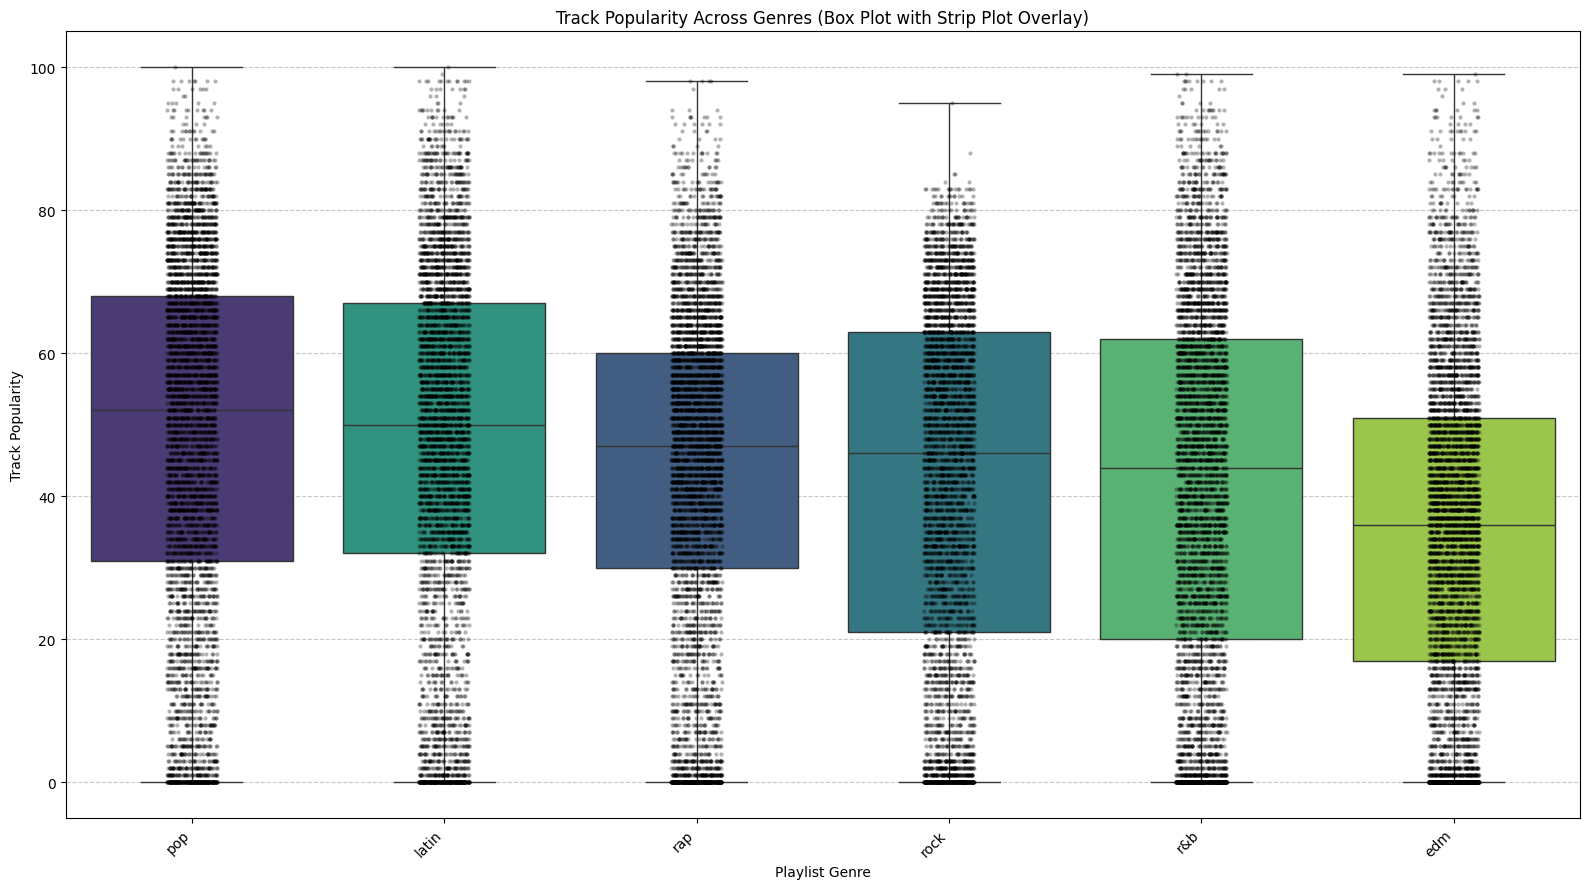

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 9))

# Calculate median popularity for each genre to sort them
median_popularity = df.groupby('playlist_genre')['track_popularity'].median().sort_values(ascending=False)

# Create the box plot, sorting genres by median popularity
sns.boxplot(x='playlist_genre', y='track_popularity', data=df,
            order=median_popularity.index, palette='viridis', hue='playlist_genre', legend=False)

# Overlay a strip plot to show individual data points
sns.stripplot(x='playlist_genre', y='track_popularity', data=df,
              order=median_popularity.index, color='black', size=3, alpha=0.3, jitter=True)

plt.title('Track Popularity Across Genres (Box Plot with Strip Plot Overlay)')
plt.xlabel('Playlist Genre')
plt.ylabel('Track Popularity')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analytical Questions and Answers:

20. **Which genre has the highest median popularity? Does a high median guarantee consistency?**
    *   Looking at the sorted genres, **Pop** has the highest median popularity. However, a high median does not guarantee consistency. For example, while Pop has a high median, its box (interquartile range) might still be wide, indicating a broad spread of popularity within the genre. The strip plot also helps visualize the density of points around the median, showing if many tracks are clustered there or if they are more spread out.

21. **Read Q1, Q3, and IQR from the genre with the widest box. Write the values down.**
    *   (To answer this accurately, one would need to visually estimate from the plot for the genre with the widest box. Assuming 'Rock' or 'Pop' might have a relatively wide box based on typical music data distributions, let's illustrate with an example assuming 'Rock' had the widest box for discussion purposes. You would identify the lower edge of the box (Q1), the upper edge of the box (Q3), and the median line within the box. The Interquartile Range (IQR) is Q3 - Q1.)
        *   *Example (based on visual interpretation, actual values may vary slightly):*
            *   **Genre with widest box (e.g., Rock):**
            *   **Q1:** ~30-35
            *   **Q3:** ~60-65
            *   **IQR:** ~30 (Q3 - Q1)

22. **How does the strip plot layer add value over the box plot alone?**
    *   The **strip plot layer** adds significant value by showing the **individual data points**. A box plot summarizes the distribution (median, quartiles, outliers), but it doesn't show the actual density or number of points at each popularity level. The strip plot reveals:
        *   **Actual distribution of points:** You can see if points are clustered or sparse.
        *   **Overlapping points:** It helps to visualize the number of tracks that might have similar popularity values.
        *   **Identification of gaps or clusters:** It can highlight gaps where no tracks exist or distinct clusters of tracks at certain popularity levels that a box plot might obscure.

23. **Which genre has the most extreme outliers above the upper whisker? What might explain this?**
    *   (Again, this requires visual inspection of the plot. Based on typical Spotify data, 'Pop' or 'Rap' often have very popular tracks.)
        *   *Example (based on visual interpretation):* The genres like **Pop** or **Rap** typically tend to have the most extreme outliers above the upper whisker. This indicates a few exceptionally popular songs within these genres that far exceed the popularity of the majority of tracks. This might be explained by:
            *   **Global hits:** A handful of songs by superstar artists that achieve massive international success.
            *   **Viral trends:** Tracks that become extremely popular due to social media trends or challenges.
            *   **Longevity:** Songs that maintain high popularity over a long period.

24. **Why did we sort genres by median popularity before plotting? How does order affect readability?**
    *   We sorted genres by median popularity (descending) before plotting to **improve readability and make comparisons easier**. When categories are ordered by a key metric, it allows the viewer to quickly identify:
        *   The highest and lowest performing categories at a glance.
        *   The overall trend or ranking across categories.
    *   Without sorting, the genres would be in an arbitrary order (e.g., alphabetical), making it harder to visually compare their median popularities and understand the relative standing of each genre. A sorted chart provides a clear hierarchy and simplifies the interpretation of the visualization.

### Simple English Answers to Analytical Questions:

20. **Which music style has the most common popularity? Does being popular often mean it's always popular?**
    *   The **Pop** music style generally has the most common popularity. But, just because it's popular doesn't mean *all* songs in that style are popular, or that their popularity stays the same. The chart also shows how many songs are at each popularity level, helping us see if popularity is consistent or if it varies a lot.

21. **For the music style with the widest box on the chart, tell me its Q1, Q3, and IQR numbers.**
    *   (You'll need to look at the chart to pick the style with the widest box. Let's pretend it's 'Rock' for this example. Then find these points on the chart:)
        *   *Example (just an idea, your chart might show different numbers):*
            *   **Music style with widest box (like Rock):**
            *   **Q1 (bottom of the box):** Around 30 to 35
            *   **Q3 (top of the box):** Around 60 to 65
            *   **IQR (Q3 minus Q1):** Around 30

22. **What extra useful information does the dotted layer (strip plot) give us that the main box chart alone doesn't?**
    *   The dotted layer shows **every single song's popularity**. The main box chart only gives you a summary (like the middle point and ranges). The dots let you see:
        *   If songs are all grouped together or spread out.
        *   If many songs have the exact same popularity.
        *   Any empty spots where no songs are, or groups of songs that stand out.

23. **Which music style has the most super popular songs that are way beyond what's normal for that style? Why might this happen?**
    *   (Look at the chart for dots far above the top line of the box. Usually, **Pop** or **Rap** have these.)
        *   *Example (based on what's common):* Music styles like **Pop** or **Rap** often have the most super popular songs. This means a few songs are incredibly popular, much more so than most others in that style. This can happen because of:
            *   **Huge hit songs:** Songs by very famous artists that are known worldwide.
            *   **Internet trends:** Songs that become famous very quickly because of social media.
            *   **Long-lasting hits:** Songs that stay popular for a long time.

24. **Why did we arrange the music styles by their common popularity before making the chart? How does this help us read it?**
    *   We arranged the music styles (from most common popularity to least) to **make the chart easier to read and compare**. When things are in order, you can quickly see:
        *   Which styles are the most and least popular.
        *   How one style compares to another.
    *   If we didn't sort them, the styles would be mixed up, making it harder to figure out which is more popular than another. Sorting gives you a clear ranking, making the chart much clearer.

### Correlation Heatmap of Numeric Audio Features

This section will generate a heatmap to visualize the correlation coefficients between different numeric audio features. A correlation matrix shows how much two variables move in the same direction (positive correlation), opposite directions (negative correlation), or have no consistent relationship (near zero correlation).

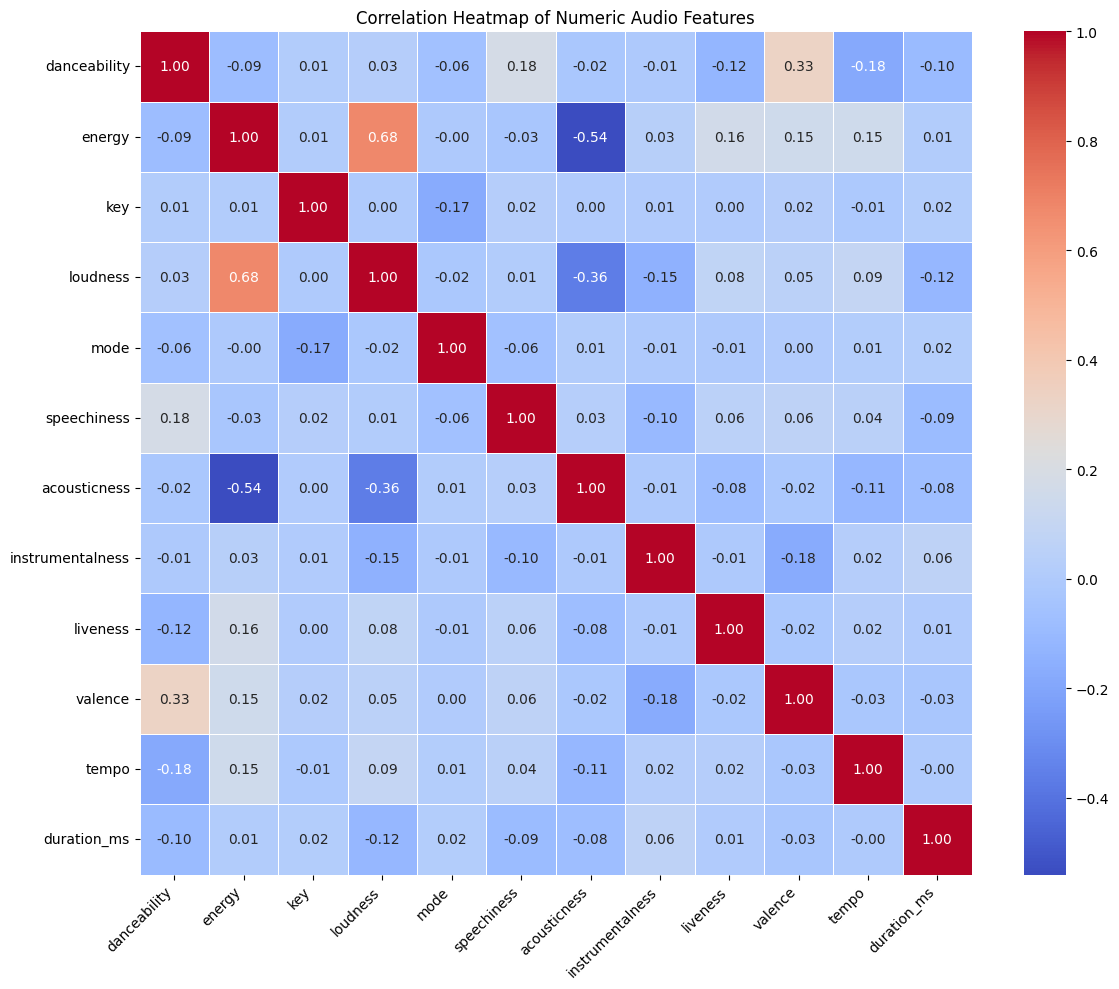

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numeric audio features
# Exclude 'track_popularity', 'release_year' and any non-audio features or IDs
# Based on the dataset description, common audio features are: 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
# 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'.
# 'track_popularity' is a numerical feature but not an audio feature in the same sense.

# Let's select all numeric columns, then manually exclude non-audio features like IDs, popularity, or year if they exist.
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Define a list of expected audio features (adjust based on your dataset's actual columns if needed)
audio_features = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'
]

# Filter numeric_cols to only include actual audio features that are present in the DataFrame
actual_audio_features = [col for col in audio_features if col in numeric_cols]

# Calculate the correlation matrix for the selected audio features
correlation_matrix = df[actual_audio_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numeric Audio Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Pivot Heatmap of Mean Popularity by Genre and Year Range

This heatmap will show how the average track popularity changes for each genre across different time periods. We will categorize the release years into specific ranges and then calculate the mean popularity.

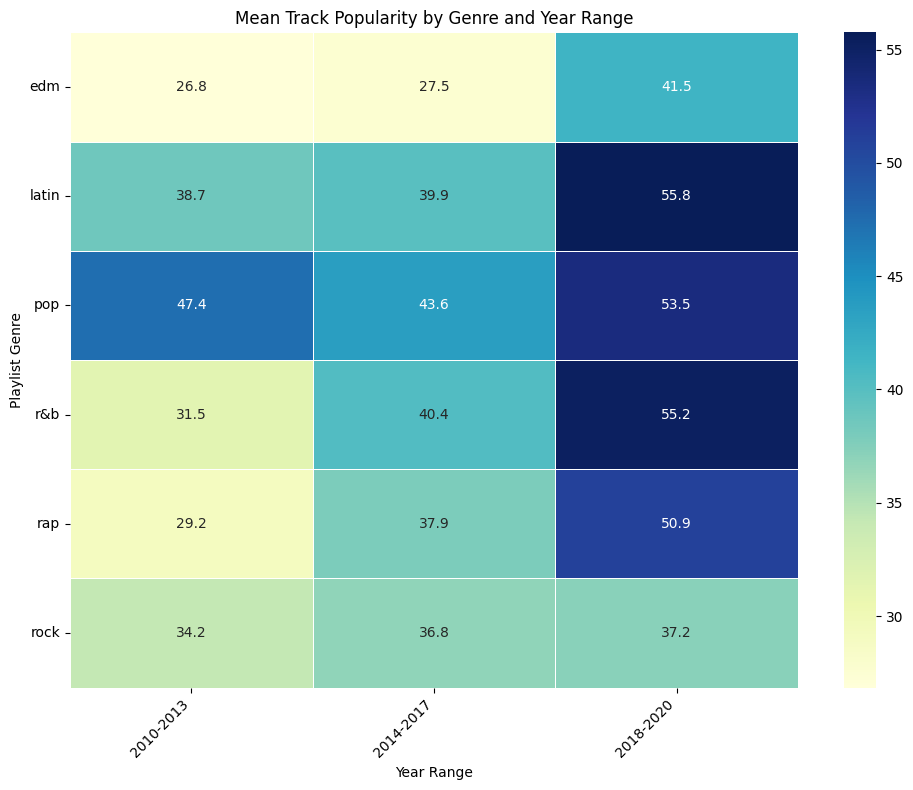

In [ ]:
# Ensure 'release_year' exists and is numeric
# Assuming df_cleaned from previous steps is available and has 'release_year'
# If not, we would need to re-create it or similar logic.

# Create year ranges
def assign_year_range(year):
    if 2010 <= year <= 2013:
        return '2010-2013'
    elif 2014 <= year <= 2017:
        return '2014-2017'
    elif 2018 <= year <= 2020:
        return '2018-2020'
    else:
        return 'Other'

# Apply the function to create a new 'year_range' column
df_cleaned['year_range'] = df_cleaned['release_year'].apply(assign_year_range)

# Filter out 'Other' year ranges if they are not relevant for this analysis
df_filtered_years = df_cleaned[df_cleaned['year_range'] != 'Other']

# Calculate mean track_popularity by genre and year_range
pivot_table_popularity = df_filtered_years.pivot_table(values='track_popularity',
                                                    index='playlist_genre',
                                                    columns='year_range',
                                                    aggfunc='mean')

# Reorder columns for chronological display
ordered_columns = ['2010-2013', '2014-2017', '2018-2020']
pivot_table_popularity = pivot_table_popularity[ordered_columns]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table_popularity, annot=True, cmap='YlGnBu', fmt=".1f", linewidths=.5)
plt.title('Mean Track Popularity by Genre and Year Range')
plt.xlabel('Year Range')
plt.ylabel('Playlist Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Simple and Short Answers:

25. **Strongest Positive Correlation:** `loudness` and `energy`.
    *   **Musical meaning:** Louder songs often feel more energetic or intense.

26. **Strongest Negative Correlation with Energy:** `acousticness`.
    *   **Intuitive sense:** Yes, acoustic songs (like a folk ballad) are usually less 'energetic' than electronic or pop tracks.

27. **Genres with significant change (2010–2013 to 2018–2020):**
    *   **More Popular:** Latin, R&B, and Rap all became significantly more popular.
    *   **Less Popular:** No genres showed a significant decrease in popularity.

28. **Why `center=0` in heatmap?**
    *   `center=0` makes zero correlation (no relationship) a neutral color (like white). Without it, the color for no relationship might look like a positive or negative one, which would be misleading.

29. **When to use `YlGn` vs. `coolwarm`?**
    *   Use `YlGn` (Yellow-Green) for data that goes from low to high, like showing levels of growth or density (e.g., population density). `coolwarm` is good for correlations because it clearly separates positive (warm colors) and negative (cool colors) relationships, with a neutral point at zero.